# 02 — Stylised facts of one share's returns

**Workstream B** of the group project plan. The brief asks for one share, examined at daily, weekly and
monthly frequency, against six stylised facts — and is explicit that we **assess** each one rather than
assume it holds. This notebook produces every table and figure report section 3 (*Stylised facts*) is
anchored on, and ends with the verdict table that section opens with.

| Task | Output |
| --- | --- |
| B1, B4 | **Table 2.1 — Descriptive statistics and normality tests** |
| B2 | **Figure 2.1 — Log returns over time** |
| B3 | **Figure 2.2 — Return distribution** (daily; weekly and monthly in Figure A2.1) |
| B5 | **Table 2.2 — Tail quantiles** (plus Table A2.1, exceedance counts) |
| B6, B7 | **Figure 2.3a–c — ACF of raw, absolute and squared returns** (weekly/monthly in Figures A2.2–A2.3) |
| B6, B8 | **Table 2.3 — Serial dependence and ARCH tests** |
| B9, B10 | **Table 2.4 — Volatility models** (daily; weekly and monthly in Table A2.2) |
| B10b | **Tables A2.3–A2.4 — Robustness**: the crisis window, sub-samples, mean specification |
| B11 | **Figure 2.4 — News impact curve** |
| B12 | **Figure 2.5 — Standardised residuals** + residual rows in Table 2.1 |
| B13 | **Table 2.5 — Stylised facts summary** |

Shared code: `src/stylised.py` (statistics, tests, models, verdict rules) and `src/viz.py` (figures).
All returns are **log returns in percent**, from the panel built in notebook 01. The share is
`cfg.STYLISED_FACTS_TICKER` (currently `JPM`); no cell names it, and every number quoted in the
commentary is printed by a cell above it.

## Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src import config as cfg
from src import data, fmt, stylised as sf, viz

viz.use_house_style()
np.random.seed(cfg.SEED)  # nothing here is random, but the seed is fixed everywhere

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)

TICKER = cfg.STYLISED_FACTS_TICKER

---

## Data

The panel is rebuilt exactly as in notebook 01 — nothing is read from disk. The stylised-facts sample is
the **full 15-year panel**; the share has data throughout.

Weekly and monthly series keep **complete periods only**. The first week and month always miss the move
into the panel's first session, and an extraction mid-month leaves a stub of a few sessions at the end;
both would be returns over a shorter horizon than their label claims, so they are dropped.

In [2]:
close, volume, extraction_date = data.download_raw()
panel = data.build_panel(close, volume, extraction_date)
returns = data.build_returns(panel)
r = sf.share_returns(returns, panel.calendar, TICKER)

print(f"Extraction date : {extraction_date.isoformat()}")
print(f"Share           : {TICKER} — {cfg.UNIVERSE[TICKER]['name']} ({cfg.UNIVERSE[TICKER]['instrument']})")
for frequency, series in r.items():
    print(f"{frequency:<8}: n = {len(series):>5,}   {series.index[0].date()} to {series.index[-1].date()}")

Extraction date : 2026-10-07
Share           : JPM — JPMorgan Chase (Common stock)
daily   : n = 3,773   2011-10-04 to 2026-10-06
weekly  : n =   782   2011-10-14 to 2026-10-02
monthly : n =   179   2011-11-30 to 2026-09-30


---

## B1, B4 — Table 2.1, descriptive statistics and normality tests

Three normality tests, because they look at different things. **Jarque–Bera** tests skewness and
kurtosis jointly; **Shapiro–Wilk** is the most powerful omnibus test in moderate samples; **Anderson–
Darling** weights the tails most heavily. Kurtosis is **excess** kurtosis throughout: 0 for a normal,
with the D'Agostino test of whether it is significantly non-zero.

**Skewness is tested differently, and the reason matters.** The textbook skewness test assumes the data
are normal. Under fat tails the sampling error of skewness is driven by the most extreme days, and the
textbook standard error is several times too small, so the test "finds" skew in what is really a few
outliers. It is the same problem Ljung–Box has under volatility clustering (B6). So both skewness
measures are tested by a **moving-block bootstrap** that resamples the data as they are, fat tails and
clustering included:

- **Skew** — the usual moment skewness, dominated by the largest moves.
- **Q-skew** — quantile skewness at the 5th and 95th percentiles: whether the lower tail reaches further
  from the median than the upper one, unaffected by a handful of extreme days.

The residual rows (B12) are added below, once the volatility model is fitted.

In [3]:
descriptive = sf.descriptive_table(r)

TABLE_2_1_RULES = {
    "n": fmt.count,
    **{c: (lambda v: fmt.percent(v, 2)) for c in ["Mean %", "SD %", "Min %", "Max %"]},
    **{c: (lambda v: fmt.number(v, 2)) for c in ["Skew", "Q-skew", "Excess kurtosis", "JB stat", "AD stat"]},
    "SW stat": lambda v: fmt.number(v, 3),
    **{c: fmt.pvalue for c in ["Skew p", "Q-skew p", "Kurtosis p", "JB p", "SW p", "AD p"]},
}

def period(frequency):
    s = r[frequency]
    return f"{s.index[0]:%Y-%m} to {s.index[-1]:%Y-%m}"

print(f"Table 2.1 - Descriptive statistics, {TICKER} log returns. {period('daily')}; "
      f"n = {len(r['daily']):,} / {len(r['weekly']):,} / {len(r['monthly']):,} (daily / weekly / monthly). "
      "Per-period, not annualised. Kurtosis is excess kurtosis. Skew and Q-skew p-values from a "
      f"moving-block bootstrap ({sf.BOOTSTRAP_DRAWS:,} draws, seed {cfg.SEED}).")
display(fmt.style(descriptive, TABLE_2_1_RULES))

# How far off the textbook skewness standard error is, at each frequency.
for frequency, series in r.items():
    n = len(series)
    textbook = np.sqrt(6 * (n - 2) / ((n + 1) * (n + 3)))
    boot = sf.block_bootstrap(series.to_numpy(), lambda b: stats.skew(b, axis=1)).std()
    print(f"{frequency:<8} skewness SE: textbook {textbook:.3f}, bootstrap {boot:.3f}  (x{boot / textbook:.1f})")

Table 2.1 - Descriptive statistics, JPM log returns. 2011-10 to 2026-10; n = 3,773 / 782 / 179 (daily / weekly / monthly). Per-period, not annualised. Kurtosis is excess kurtosis. Skew and Q-skew p-values from a moving-block bootstrap (2,000 draws, seed 20261001).


,n,Mean %,SD %,Min %,Max %,Skew,Skew p,Q-skew,Q-skew p,Excess kurtosis,Kurtosis p,JB stat,JB p,SW stat,SW p,AD stat,AD p
Series,,,,,,,,,,,,,,,,,
daily,"3,773",0.08,1.68,-16.21,16.56,-0.08,0.779,-0.05,0.035,11.08,<0.001,19291.68,<0.001,0.907,<0.001,55.80,<0.001
weekly,782,0.36,3.59,-21.87,20.10,-0.34,0.204,-0.13,0.004,4.06,<0.001,552.02,<0.001,0.959,<0.001,4.97,<0.001
monthly,179,1.48,6.98,-25.97,19.50,-0.66,0.029,-0.13,0.111,1.73,0.002,35.53,<0.001,0.970,<0.001,0.93,0.018


daily    skewness SE: textbook 0.040, bootstrap 0.260  (x6.5)
weekly   skewness SE: textbook 0.087, bootstrap 0.268  (x3.1)
monthly  skewness SE: textbook 0.180, bootstrap 0.308  (x1.7)


Two things are visible before any test. **The tails are very fat at daily frequency and thin out as
returns aggregate** — excess kurtosis falls from about 11 to about 4 weekly and under 2 monthly — which
is what the central limit theorem predicts for sums of weakly dependent shocks. Even monthly, all three
normality tests reject.

**Skewness is negative at every frequency, but fragile.** Moment skewness grows more negative with the
horizon (about −0.08, −0.34, −0.66), yet the bootstrap shows why the textbook test cannot be trusted
here: its standard error is roughly six times too small at daily frequency. With the honest standard
error, moment skewness is significant only monthly. Quantile skewness is negative and significant at
daily and weekly frequency. The lower tail of the *body* of the distribution genuinely reaches further
than the upper one, even if the extreme days do not settle the question. Hence *Partial* throughout
(Table 2.5), not the *Supported* the textbook test would have given.

---

## B2 — Figure 2.1, log returns over time

Each panel has its own y-scale: a monthly move is the sum of about 21 daily ones, so a shared scale would
flatten the daily series and hide the clustering this figure is for.

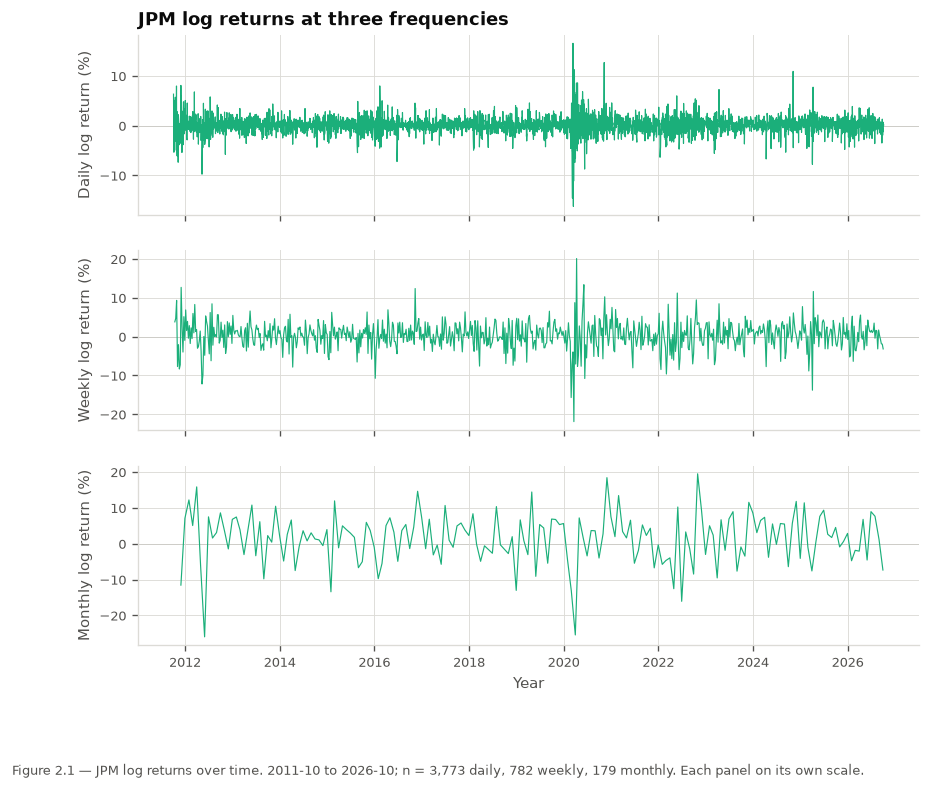

In [4]:
fig, axes = viz.return_panels(r, TICKER)
axes[0].set_title(f"{TICKER} log returns at three frequencies")
viz.caption(
    axes[-1],
    f"Figure 2.1 — {TICKER} log returns over time. {period('daily')}; "
    f"n = {len(r['daily']):,} daily, {len(r['weekly']):,} weekly, {len(r['monthly']):,} monthly. "
    "Each panel on its own scale.",
)
plt.show()

The daily panel shows the clustering directly: calm stretches alternate with bursts, and large moves
sit next to large moves. March 2020 dominates, with moves of ±16% on consecutive days, but it is not
alone: the European debt crisis at the start of the panel, the 2012 trading loss, the 2015–16 sell-off,
the 2022 rate shock, the March 2023 regional-bank failures, the November 2024 election rally and the
April 2025 tariff shock all show as clusters. The
monthly panel is much harder to read the same way, which anticipates the absent monthly evidence in
Table 2.3.

---

## B3 — Figure 2.2, return distribution

The histogram sits against a normal with the **same mean and standard deviation**, so any difference is
shape alone. On the Q–Q plot, points above the line on the right and below it on the left are fat tails.
The main report shows daily; weekly and monthly go to the appendix as Figure A2.1.

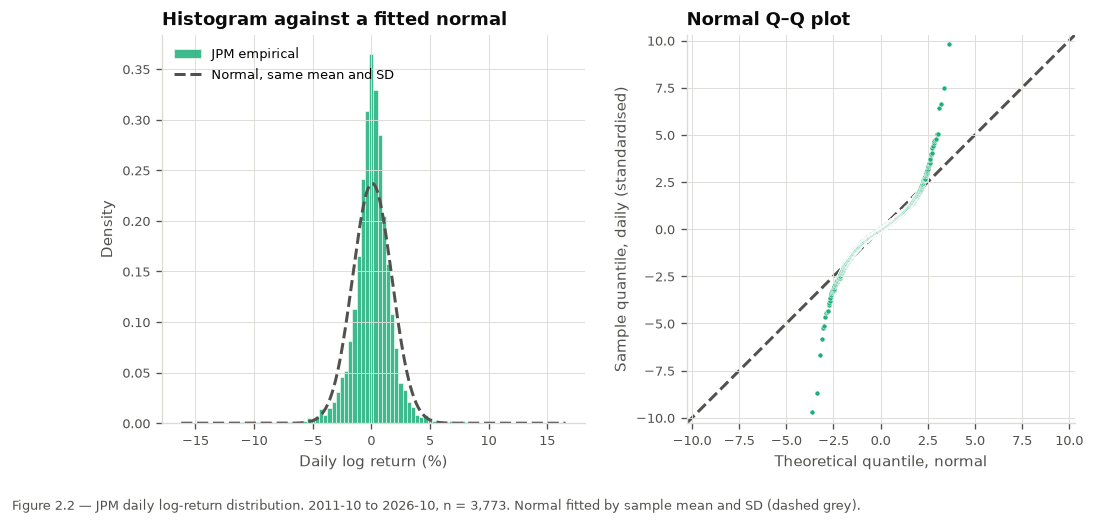

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))
viz.distribution_pair(r["daily"], TICKER, axes, label="Daily")
axes[0].set_title("Histogram against a fitted normal")
axes[1].set_title("Normal Q–Q plot")
viz.caption(
    axes[0],
    f"Figure 2.2 — {TICKER} daily log-return distribution. {period('daily')}, n = {len(r['daily']):,}. "
    "Normal fitted by sample mean and SD (dashed grey).",
)
plt.show()

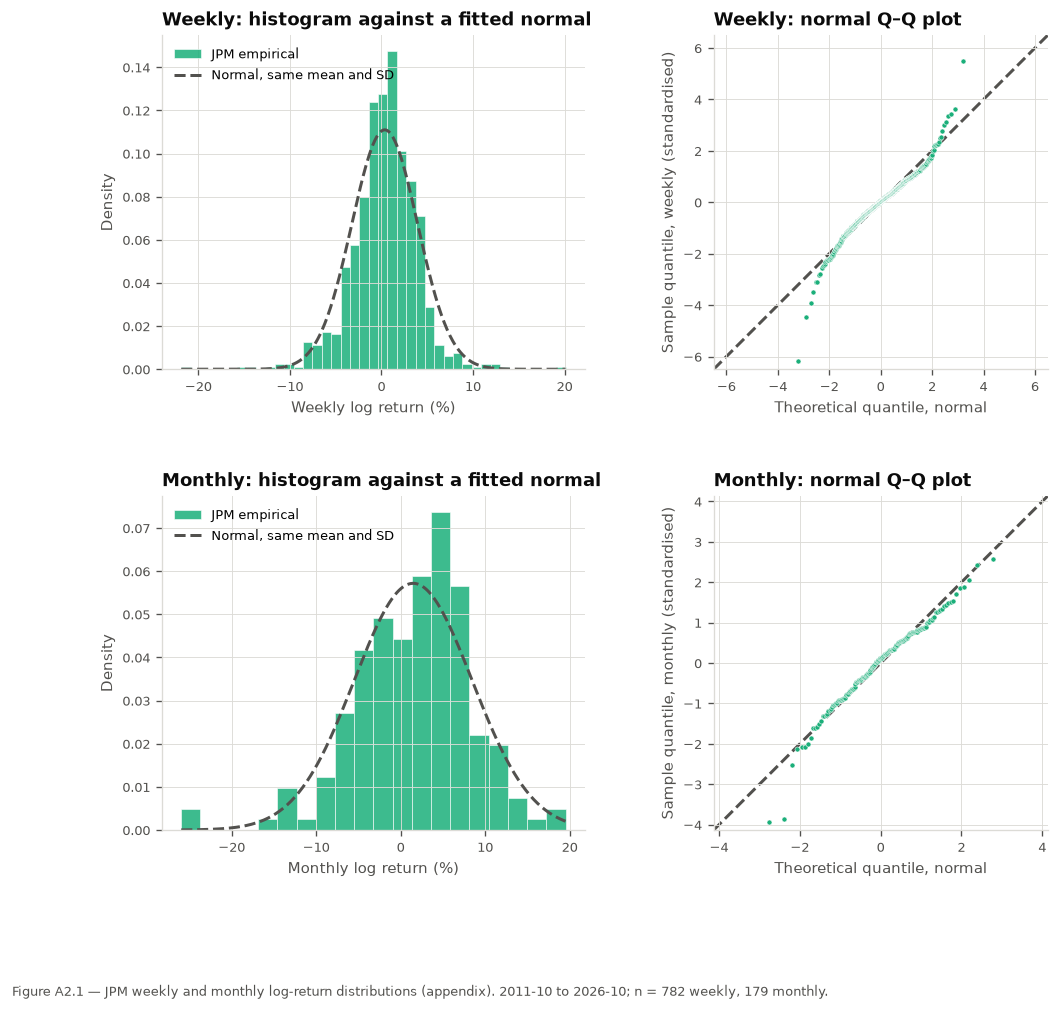

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10.0, 8.6))
fig.subplots_adjust(hspace=0.38)
for row, frequency in zip(axes, ["weekly", "monthly"]):
    viz.distribution_pair(r[frequency], TICKER, row, label=frequency.capitalize())
    row[0].set_title(f"{frequency.capitalize()}: histogram against a fitted normal")
    row[1].set_title(f"{frequency.capitalize()}: normal Q–Q plot")
viz.caption(
    axes[1, 0],
    f"Figure A2.1 — {TICKER} weekly and monthly log-return distributions (appendix). {period('weekly')}; "
    f"n = {len(r['weekly']):,} weekly, {len(r['monthly']):,} monthly.",
)
plt.show()

---

## B5 — Table 2.2, tail quantiles

Empirical quantiles against those of the moment-matched normal. The ratio is measured from the mean, so
it reads the same way in both tails: above 1 means the empirical tail is further out than the normal
puts it.

In [7]:
tails = sf.tail_table(r)
print(f"Table 2.2 - Tail quantiles, {TICKER} log returns, empirical against a normal with the sample "
      f"mean and SD. {period('daily')}. Ratio measured from the mean.")
display(fmt.style(tails.reset_index(), {
    "Quantile %": lambda v: fmt.number(v, 0),
    "Empirical %": lambda v: fmt.percent(v, 2),
    "Normal-implied %": lambda v: fmt.percent(v, 2),
    "Ratio": lambda v: fmt.number(v, 2),
}).set_index(["Frequency", "Quantile %"]))

Table 2.2 - Tail quantiles, JPM log returns, empirical against a normal with the sample mean and SD. 2011-10 to 2026-10. Ratio measured from the mean.


Empirical % Normal-implied % Ratio
Frequency Quantile %                                   
daily     1                -4.53            -3.84  1.18
          5                -2.51            -2.69  0.94
          95                2.45             2.84  0.86
          99                4.56             3.99  1.14
weekly    1                -8.98            -8.01  1.12
          5                -5.68            -5.56  1.02
          95                5.33             6.27  0.84
          99                9.36             8.72  1.08
monthly   1               -18.12           -14.75  1.21
          5                -9.75           -10.00  0.98
          95               11.57            12.96  0.88
          99               16.42            17.71  0.92

In [8]:
exceed = sf.exceedance_table(r)
print("Table A2.1 - Moves beyond k standard deviations, observed against the normal-expected count "
      f"(appendix). {period('daily')}.")
display(fmt.style(exceed.reset_index(), {
    "Observed": fmt.count,
    "Normal-expected": lambda v: fmt.number(v, 3),
    # No more precision than the estimate supports: a ratio in the thousands is a count.
    "Ratio": lambda v: fmt.number(v, 1) if v < 100 else fmt.count(v),
}).set_index(["Frequency", "Beyond ±kσ"]))

Table A2.1 - Moves beyond k standard deviations, observed against the normal-expected count (appendix). 2011-10 to 2026-10.


Observed Normal-expected  Ratio
Frequency Beyond ±kσ                                
daily     3                54          10.186    5.3
          4                25           0.239    105
          5                12           0.002  5,548
weekly    3                12           2.111    5.7
          4                 3           0.050   60.6
          5                 2           0.000  4,461
monthly   3                 2           0.483    4.1
          4                 0           0.011    0.0
          5                 0           0.000    0.0

The quantile table shows the characteristic fat-tail signature: at daily frequency the **5% and 95%
quantiles sit *inside* the normal's** (ratio below 1 — the distribution is more peaked) while the **1%
and 99% sit outside** it. The exceedance counts make the same point more starkly: daily moves beyond
4σ and 5σ occur many times more often than a normal allows. At monthly frequency the two tails part
company: the 1% quantile still sits well outside the normal's (ratio about 1.2) while the 99% sits
inside it (about 0.9) — the lower tail is fat and the upper is not, which is the negative skew of
Table 2.1 seen through quantiles. The monthly extreme-move counts are too small to say more.

---

## B6, B7, B8 — serial dependence and volatility clustering

The same tool answers two different questions. The ACF of **raw** returns tests whether the *direction*
of returns is predictable (fact 1). The ACF of **absolute** and **squared** returns tests whether the
*size* of returns is (fact 4). Drawing them side by side on one scale is the argument.

**One methodological point decides fact 1.** The usual ±1.96/√n band and the Ljung–Box test both assume
iid returns. When volatility clusters — which the right-hand panels show it does — they **over-reject**:
a few huge-variance days make sample autocorrelations noisier than the band allows. So we also report a
**heteroskedasticity-robust** band and portmanteau test (each lag's variance estimated from the
cross-products r_t·r_{t−k}), and the fact-1 verdict is judged on the robust version.

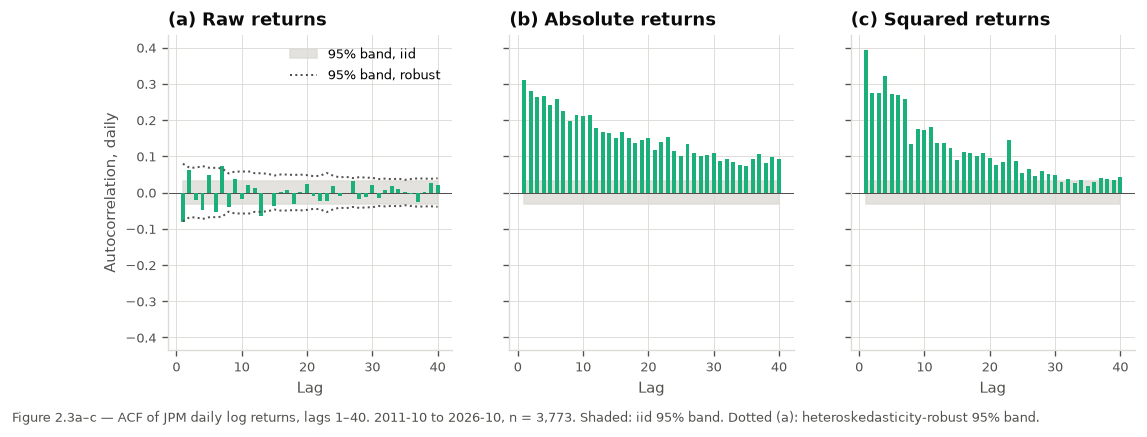

In [9]:
acfs = {frequency: sf.acf_frame(series) for frequency, series in r.items()}

fig, axes = viz.acf_panels(acfs["daily"], TICKER, label="daily")
for ax, letter in zip(axes, "abc"):
    ax.set_title(f"({letter}) {ax.get_title(loc='left')}", loc="left")
viz.caption(
    axes[0],
    f"Figure 2.3a–c — ACF of {TICKER} daily log returns, lags 1–{sf.ACF_LAGS}. {period('daily')}, "
    f"n = {len(r['daily']):,}. Shaded: iid 95% band. Dotted (a): heteroskedasticity-robust 95% band.",
)
plt.show()

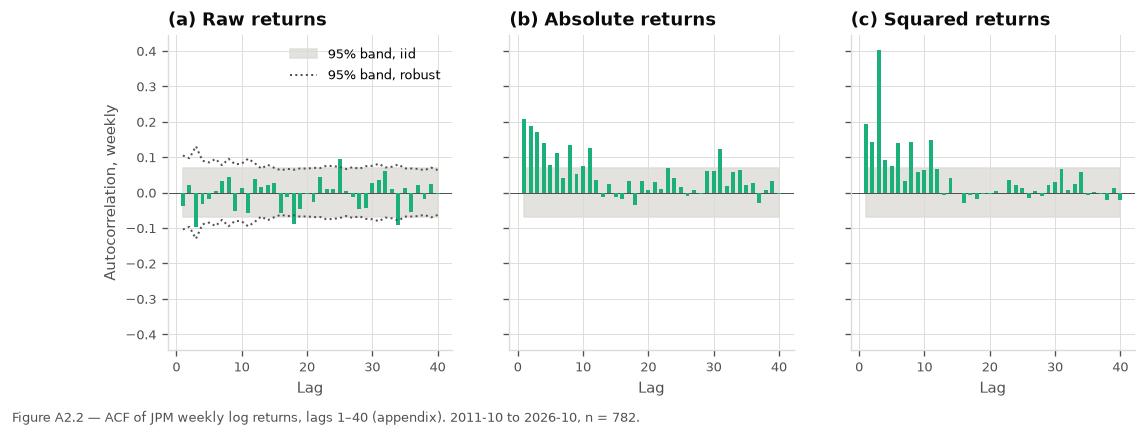

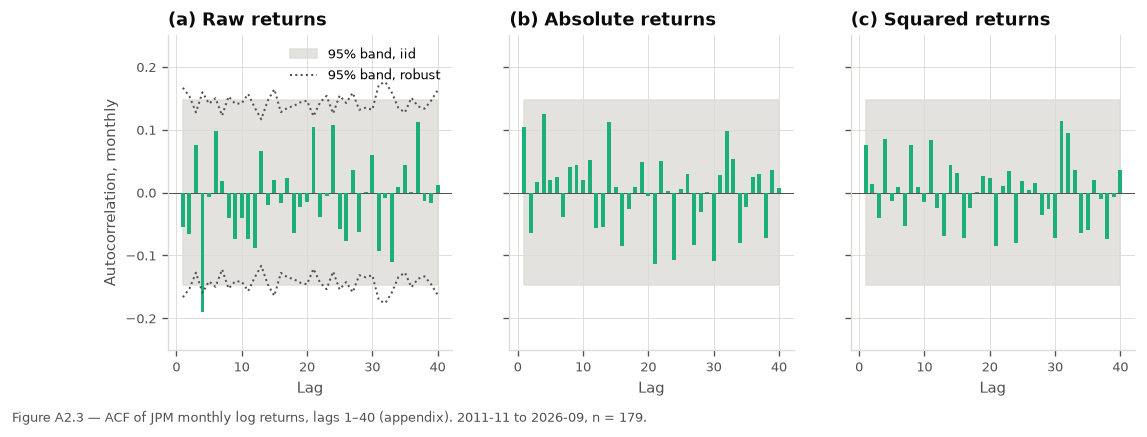

In [10]:
for number, frequency in (("A2.2", "weekly"), ("A2.3", "monthly")):
    fig, axes = viz.acf_panels(acfs[frequency], TICKER, label=frequency)
    for ax, letter in zip(axes, "abc"):
        ax.set_title(f"({letter}) {ax.get_title(loc='left')}", loc="left")
    viz.caption(
        axes[0],
        f"Figure {number} — ACF of {TICKER} {frequency} log returns, lags 1–{sf.ACF_LAGS} (appendix). "
        f"{period(frequency)}, n = {len(r[frequency]):,}.",
    )
    plt.show()

In [11]:
dependence = sf.dependence_table(r)
print(f"Table 2.3 - Serial dependence and ARCH tests, {TICKER} log returns. Ljung-Box Q and the robust "
      f"portmanteau Q* are chi-squared with k degrees of freedom; ARCH-LM is the LM statistic on k lags "
      f"of squared demeaned returns. {period('daily')}.")
display(fmt.style(dependence, {
    **{f"Q({k})": (lambda v: fmt.number(v, 2)) for k in sf.LB_LAGS},
    **{f"p({k})": fmt.pvalue for k in sf.LB_LAGS},
}))

Table 2.3 - Serial dependence and ARCH tests, JPM log returns. Ljung-Box Q and the robust portmanteau Q* are chi-squared with k degrees of freedom; ARCH-LM is the LM statistic on k lags of squared demeaned returns. 2011-10 to 2026-10.


Q(5)    p(5)    Q(10)   p(10)    Q(20)   p(20)
Frequency Test                                                                      
daily     Ljung–Box, raw             59.18  <0.001   102.11  <0.001   131.55  <0.001
          Ljung–Box, absolute      1410.84  <0.001  2341.53  <0.001  3359.54  <0.001
          Ljung–Box, squared       1824.54  <0.001  2644.65  <0.001  3204.71  <0.001
          Robust portmanteau, raw    11.22   0.047    22.20   0.014    33.70   0.028
          ARCH-LM                   849.52  <0.001   923.89  <0.001   944.32  <0.001
weekly    Ljung–Box, raw              9.84   0.080    14.47   0.153    30.69   0.059
          Ljung–Box, absolute       104.53  <0.001   136.18  <0.001   153.52  <0.001
          Ljung–Box, squared        183.89  <0.001   222.03  <0.001   245.94  <0.001
          Robust portmanteau, raw     3.45   0.631     6.73   0.750    23.32   0.273
          ARCH-LM                   148.98  <0.001   166.10  <0.001   177.82  <0.001
monthly   Ljung–Box, raw              9.07   0.106    12.58   0.248    17.34   0.631
          Ljung–Box, absolute         5.80   0.326     6.95   0.730    13.24   0.867
          Ljung–Box, squared          2.76   0.738     4.47   0.924     8.80   0.985
          Robust portmanteau, raw     8.09   0.152    11.57   0.315    17.03   0.651
          ARCH-LM                     2.60   0.761     5.80   0.832    14.34   0.813

In [12]:
for frequency in cfg.FREQUENCY_ORDER:
    a = acfs[frequency]
    print(f"{frequency:<8} lag-1 ρ = {a.loc[1, 'raw']:+.3f}   iid band ±{a.loc[1, 'band']:.3f}   "
          f"robust band ±{a.loc[1, 'robust_band']:.3f}   "
          f"lag-1 ρ of |r| = {a.loc[1, 'absolute']:.3f}")

daily    lag-1 ρ = -0.082   iid band ±0.032   robust band ±0.079   lag-1 ρ of |r| = 0.309
weekly   lag-1 ρ = -0.037   iid band ±0.070   robust band ±0.104   lag-1 ρ of |r| = 0.209
monthly  lag-1 ρ = -0.055   iid band ±0.146   robust band ±0.167   lag-1 ρ of |r| = 0.105


**Fact 1 is a frequency story, and at daily frequency a crisis story.** At weekly and monthly frequency
every robust test fails to reject: no serial correlation, as the fact predicts. At **daily** frequency
the robust portmanteau rejects, driven by a **negative lag-1 autocorrelation of about −0.08** — small,
under 1% of next-day variance, well inside the round-trip cost of trading on it. Hence *Partial*.

Where it comes from is shown in B10b (Table A2.3): **without the COVID crash weeks, the daily lag-1
autocorrelation is −0.02 and the robust test no longer rejects**. The effect is the whipsaw of March
2020 — a −15% day, a +17% day, a −16% day — not a persistent property of the share.

Plain Ljung–Box on raw daily returns rejects with p < 0.001 at every lag; the robust test only at
p ≈ 0.01–0.05. That gap is the over-rejection the robust version exists to remove.

**Fact 4 is clear in the other direction at daily and weekly frequency.** The absolute and squared ACFs
are positive and decay slowly — the clustering signature — and every test rejects. **At monthly
frequency none of the nine tests rejects**: clustering is a short-horizon phenomenon for this share,
gone once returns are summed over a month.

---

## B9, B10 — Table 2.4, volatility models

Four GARCH-family models, constant mean, on percent log returns:

| Model | What it adds |
| --- | --- |
| GARCH(1,1), normal | The baseline: σ²_t = ω + α ε²_{t−1} + β σ²_{t−1} |
| GARCH(1,1), Student-t | Same variance equation; fat-tailed errors with ν degrees of freedom |
| GJR-GARCH(1,1), t | Adds γ ε²_{t−1}·1[ε_{t−1} < 0]: **γ > 0 is the leverage effect** |
| EGARCH(1,1), t | Log-variance with a signed term γ z_{t−1}: **γ < 0 is the leverage effect** |

GARCH-N against GARCH-t isolates the error assumption; GJR and EGARCH are two different
parameterisations of the same asymmetry question, so a leverage effect that is real should show up in
both. Persistence is α + β (+ γ/2 for GJR), or β for EGARCH; the **half-life**, ln 0.5 / ln(persistence), is
the number of periods a volatility shock takes to decay by half.

In [13]:
fits = {frequency: sf.fit_models(series, frequency) for frequency, series in r.items()}
model_tables = {frequency: sf.model_table(f) for frequency, f in fits.items()}

MODEL_RULES = {}
for model in sf.MODELS:
    MODEL_RULES[(model, "Estimate")] = lambda v: fmt.number(v, 4)
    MODEL_RULES[(model, "SE")] = lambda v: fmt.number(v, 4)
    MODEL_RULES[(model, "p")] = fmt.pvalue

def show_model_table(frequency, number):
    t = model_tables[frequency].copy()
    styled = t.copy().astype(object)
    for col, rule in MODEL_RULES.items():
        styled[col] = t[col].map(rule)
    # Fit statistics carry no standard error; log-likelihood and ICs need no 4 dp.
    for row in ["Half-life", "Log-likelihood", "AIC", "BIC"]:
        for model in sf.MODELS:
            styled.loc[row, (model, "Estimate")] = fmt.number(t.loc[row, (model, "Estimate")], 1)
    for model in sf.MODELS:
        styled.loc["Converged", (model, "Estimate")] = "Yes" if t.loc["Converged", (model, "Estimate")] else "No"
    print(f"Table {number} - Volatility models, {TICKER} {frequency} log returns (%), constant mean. "
          f"{period(frequency)}, n = {len(r[frequency]):,}. Quasi-ML robust standard errors.")
    display(styled.fillna(fmt.NA))

show_model_table("daily", "2.4")

Table 2.4 - Volatility models, JPM daily log returns (%), constant mean. 2011-10 to 2026-10, n = 3,773. Quasi-ML robust standard errors.


GARCH-N                  GARCH-t                    GJR-t                 EGARCH-t                
               Estimate      SE       p Estimate      SE       p Estimate      SE       p Estimate      SE       p
Parameter                                                                                                         
μ                0.1089  0.0228  <0.001   0.1103  0.0193  <0.001   0.0905  0.0195  <0.001   0.0867  0.0195  <0.001
ω                0.1087  0.0521   0.037   0.0885  0.0329   0.007   0.0765  0.0344   0.026   0.0245  0.0075   0.001
α                0.0873  0.0281   0.002   0.0923  0.0233  <0.001   0.0193  0.0142   0.174   0.1374  0.0277  <0.001
γ                     —       —       —        —       —       —   0.1158  0.0334  <0.001  -0.0933  0.0129  <0.001
β                0.8677  0.0467  <0.001   0.8739  0.0331  <0.001   0.8916  0.0379  <0.001   0.9751  0.0070  <0.001
ν                     —       —       —   4.8052  0.3742  <0.001   5.0097  0.4037  <0.001   5.1147  0.4194  <0.001
Persistence      0.9550       —       —   0.9662       —       —   0.9688       —       —   0.9751       —       —
Half-life          15.1       —       —     20.2       —       —     21.8       —       —     27.5       —       —
Log-likelihood  -6796.1       —       —  -6607.1       —       —  -6580.6       —       —  -6568.6       —       —
AIC             13600.1       —       —  13224.2       —       —  13173.2       —       —  13149.2       —       —
BIC             13625.1       —       —  13255.4       —       —  13210.6       —       —  13186.7       —       —
Converged           Yes       —       —      Yes       —       —      Yes       —       —      Yes       —       —

In [14]:
show_model_table("weekly", "A2.2a")
show_model_table("monthly", "A2.2b")

Table A2.2a - Volatility models, JPM weekly log returns (%), constant mean. 2011-10 to 2026-10, n = 782. Quasi-ML robust standard errors.


GARCH-N                  GARCH-t                    GJR-t                 EGARCH-t                
               Estimate      SE       p Estimate      SE       p Estimate      SE       p Estimate      SE       p
Parameter                                                                                                         
μ                0.4534  0.1114  <0.001   0.5023  0.1064  <0.001   0.4131  0.1087  <0.001   0.3954  0.1085  <0.001
ω                1.8440  0.6605   0.005   1.3012  0.7873   0.098   1.0475  0.4863   0.031   0.2053  0.0905   0.023
α                0.1418  0.0452   0.002   0.1239  0.0578   0.032   0.0000  0.0364   1.000   0.1417  0.0518   0.006
γ                     —       —       —        —       —       —   0.1950  0.0650   0.003  -0.1812  0.0418  <0.001
β                0.7046  0.0742  <0.001   0.7663  0.1103  <0.001   0.8058  0.0770  <0.001   0.9126  0.0365  <0.001
ν                     —       —       —   6.6946  1.4746  <0.001   7.4402  1.8046  <0.001   7.2299  1.6559  <0.001
Persistence      0.8463       —       —   0.8902       —       —   0.9033       —       —   0.9126       —       —
Half-life           4.2       —       —      6.0       —       —      6.8       —       —      7.6       —       —
Log-likelihood  -2054.7       —       —  -2034.1       —       —  -2024.4       —       —  -2025.0       —       —
AIC              4117.3       —       —   4078.1       —       —   4060.8       —       —   4061.9       —       —
BIC              4136.0       —       —   4101.4       —       —   4088.7       —       —   4089.9       —       —
Converged           Yes       —       —      Yes       —       —      Yes       —       —      Yes       —       —

Table A2.2b - Volatility models, JPM monthly log returns (%), constant mean. 2011-11 to 2026-09, n = 179. Quasi-ML robust standard errors.


GARCH-N                   GARCH-t                     GJR-t                 EGARCH-t                
               Estimate       SE       p Estimate       SE       p Estimate       SE      p Estimate      SE       p
Parameter                                                                                                           
μ                1.6279   0.4871  <0.001   1.7414   0.4882  <0.001   1.5610   0.5303  0.003   1.4224  0.5708   0.013
ω               27.9711  34.9434   0.423  42.2197  36.3096   0.245  39.6133  12.8351  0.002   0.2107  0.0938   0.025
α                0.1940   0.1868   0.299   0.1268   0.1487   0.394   0.0316   0.0719  0.661  -0.0205  0.0744   0.783
γ                     —        —       —        —        —       —   0.2957   0.2884  0.305  -0.1346  0.0577   0.020
β                0.2362   0.7967   0.767   0.0000   0.7931   1.000   0.0000   0.2371  1.000   0.9427  0.0250  <0.001
ν                     —        —       —   7.5841   3.5424   0.032  10.5072   7.9042  0.184  11.5981  8.0675   0.151
Persistence      0.4302        —       —   0.1268        —       —   0.1794        —      —   0.9427       —       —
Half-life           0.8        —       —      0.3        —       —      0.4        —      —     11.7       —       —
Log-likelihood   -598.7        —       —   -596.3        —       —   -595.7        —      —   -593.4       —       —
AIC              1205.4        —       —   1202.7        —       —   1203.3        —      —   1198.8       —       —
BIC              1218.1        —       —   1218.6        —       —   1222.5        —      —   1217.9       —       —
Converged           Yes        —       —      Yes        —       —      Yes        —      —      Yes       —       —

In [15]:
failures = pd.DataFrame(
    [
        {"Frequency": f.frequency, "Model": f.name, "Converged": f.converged,
         "Clustering identified": not f.degenerate, "Message": f.message or fmt.NA}
        for by_model in fits.values() for f in by_model.values()
        if not f.converged or f.degenerate
    ]
)
print("Estimation problems — logged, not dropped. 'Clustering identified' = at least one of α, γ "
      "significant at 5%:")
display(failures if not failures.empty else "None.")

# Parameters on a boundary (a variance term at zero) have no valid standard p-value.
for frequency, by_model in fits.items():
    for name, f in by_model.items():
        at_zero = [sf.PARAM_LABELS[k] for k in ("alpha[1]", "beta[1]") if k in f.params and abs(f.params[k]) < 1e-6]
        if at_zero:
            print(f"Boundary: {frequency} {name}, {', '.join(at_zero)} = 0 -- its p-value is not interpretable")

Estimation problems — logged, not dropped. 'Clustering identified' = at least one of α, γ significant at 5%:


,Frequency,Model,Converged,Clustering identified,Message
0,monthly,GARCH-N,True,False,—
1,monthly,GARCH-t,True,False,—
2,monthly,GJR-t,True,False,—


Boundary: weekly GJR-t, α = 0 -- its p-value is not interpretable
Boundary: monthly GARCH-t, β = 0 -- its p-value is not interpretable
Boundary: monthly GJR-t, β = 0 -- its p-value is not interpretable


**Daily.** Every model finds strong clustering, with persistence of about 0.95–0.98, which is a
**half-life of roughly 15–28 trading days**: a volatility shock fades within one to two months.
Moving from normal to Student-t errors raises the log-likelihood substantially for one extra parameter,
with **ν ≈ 5** — the conditional distribution is itself fat-tailed (fact 6, below).

**The leverage effect is strong.** GJR's γ is about 0.12 against an α of only 0.02, so almost all the
response of volatility to news comes from *bad* news; EGARCH agrees (γ ≈ −0.09). Both are significant
at p < 0.001. For a bank this is the textbook case: a falling share price raises leverage and credit
concern at once.

**Weekly** clustering is still identified, with a half-life of about 7 weeks, and the asymmetry is even
starker: GJR's α sits on its zero bound, so at weekly frequency **only negative shocks raise future
volatility**. **Monthly** clustering is not identified: the GARCH and GJR fits put β on its zero bound
with insignificant ARCH terms — 179 observations of a series with no detectable monthly clustering
(Table 2.3) cannot support a volatility model. EGARCH's monthly γ is significant, but in a model whose
other terms are not, and it is one test among many; Table 2.5 records it as *Partial* and no more.

---

## B10b — Robustness: the crisis window, sub-samples and the mean

Three checks on the verdicts that could be artefacts. **The crisis window**: March 2020 holds the
panel's most extreme days, so every headline statistic is recomputed without mid-February to mid-May
2020 (Table A2.3). **Sub-samples and the mean equation**: the leverage term is re-estimated with an
AR(1) mean, on each half of the sample (split at its midpoint date), and without the crisis window
(Table A2.4). **Rolling volatility** puts the persistence estimates in calendar terms.

In [16]:
sensitivity = sf.stress_sensitivity(r)
print(f"Table A2.3 - Sensitivity to the crisis window ({sf.STRESS_LABEL}), {TICKER} log returns "
      f"(appendix). {period('daily')}. Bootstrap p-values as in Table 2.1.")
display(fmt.style(sensitivity, {
    "n": fmt.count,
    **{c: (lambda v: fmt.number(v, 2)) for c in ["Skew", "Q-skew", "Excess kurtosis"]},
    "Lag-1 ρ": lambda v: fmt.number(v, 3),
    **{c: fmt.pvalue for c in ["Skew p", "Q-skew p", f"Q*({sf.LB_LAGS[1]}) p"]},
}))

Table A2.3 - Sensitivity to the crisis window (COVID crash, mid-Feb to mid-May 2020), JPM log returns (appendix). 2011-10 to 2026-10. Bootstrap p-values as in Table 2.1.


n   Skew Skew p Q-skew Q-skew p Excess kurtosis Lag-1 ρ Q*(10) p
Frequency Sample                                                                                
daily     Full sample       3,773  -0.08  0.779  -0.05    0.035           11.08  -0.082    0.014
          Excluding window  3,710   0.11  0.636  -0.04    0.070            5.19  -0.020    0.903
weekly    Full sample         782  -0.34  0.204  -0.13    0.004            4.06  -0.037    0.750
          Excluding window    769  -0.18  0.205  -0.11    0.017            1.58  -0.012    0.459
monthly   Full sample         179  -0.66  0.029  -0.13    0.111            1.73  -0.056    0.315
          Excluding window    176  -0.44  0.138  -0.11    0.154            1.26  -0.108    0.295

In [17]:
ASYM_RULES = {
    "n": fmt.count, "γ": lambda v: fmt.number(v, 3), "γ p": fmt.pvalue, "α": lambda v: fmt.number(v, 3),
    "Persistence": lambda v: fmt.number(v, 3), "ν": lambda v: fmt.number(v, 1),
    "Converged": lambda v: "Yes" if v else "No",
}
asymmetry = {}
for frequency, number in (("daily", "A2.4a"), ("weekly", "A2.4b")):
    asymmetry[frequency] = sf.asymmetry_robustness(r[frequency])
    print(f"Table {number} - Robustness of the GJR-t leverage term, {TICKER} {frequency} log returns (appendix).")
    display(fmt.style(asymmetry[frequency], ASYM_RULES))

Table A2.4a - Robustness of the GJR-t leverage term, JPM daily log returns (appendix).


,n,γ,γ p,α,Persistence,ν,Converged
Variant,,,,,,,
Baseline (constant mean),"3,773",0.116,<0.001,0.019,0.969,5.0,Yes
AR(1) mean,"3,772",0.115,<0.001,0.019,0.969,5.0,Yes
"First half, to 2019-04","1,886",0.126,0.002,0.022,0.961,5.0,Yes
"Second half, from 2019-04","1,887",0.099,0.021,0.010,0.978,5.0,Yes
Excluding crisis window,"3,710",0.102,0.001,0.029,0.963,4.8,Yes


Table A2.4b - Robustness of the GJR-t leverage term, JPM weekly log returns (appendix).


,n,γ,γ p,α,Persistence,ν,Converged
Variant,,,,,,,
Baseline (constant mean),782,0.195,0.003,0.000,0.903,7.4,Yes
AR(1) mean,781,0.199,0.003,0.000,0.899,7.5,Yes
"First half, to 2019-04",391,0.084,0.834,0.000,0.929,8.5,Yes
"Second half, from 2019-04",391,0.234,0.002,0.000,0.915,6.9,Yes
Excluding crisis window,769,0.168,0.054,0.044,0.844,7.9,Yes


In [18]:
rolling = sf.rolling_volatility(r["daily"]).dropna()
print(f"Rolling 63-session volatility, annualised: low {rolling.min():.1f}% ({rolling.idxmin():%Y-%m}), "
      f"high {rolling.max():.1f}% ({rolling.idxmax():%Y-%m}); full-sample {r['daily'].std() * np.sqrt(cfg.TRADING_DAYS):.1f}%")
for frequency in ("daily", "weekly"):
    f = fits[frequency][sf.PREFERRED_MODEL]
    print(f"{sf.PREFERRED_MODEL} {frequency}: persistence {f.persistence:.3f}, half-life {f.half_life:.1f} periods")

Rolling 63-session volatility, annualised: low 10.6% (2016-11), high 91.6% (2020-05); full-sample 26.7%
GJR-t daily: persistence 0.969, half-life 21.8 periods
GJR-t weekly: persistence 0.903, half-life 6.8 periods


**The daily leverage effect is robust.** γ stays between about 0.10 and 0.13 and significant in every
variant — with an AR(1) mean, in either half of the sample, and without the crisis window. It is a
property of the share, not of one episode.

**The weekly leverage effect is not.** It is significant in the second half of the sample but not in
the first (p ≈ 0.8), and without the crisis window it falls to the margin of significance (p ≈ 0.05).
The weekly *Supported* in Table 2.5 is the mechanical outcome of the rule on the full sample; the report
should qualify it.

**The crisis window moves two other verdicts.** Without it, daily serial correlation disappears
(robust p ≈ 0.9), and daily excess kurtosis halves, from about 11 to about 5 — still strongly fat-tailed.
Quantile skewness barely moves, while moment skewness does: further evidence that the moment measure
mostly reflects a few extreme days.

Rolling three-month volatility ran from about 11% (late 2016) to over 90% (spring 2020), against a
full-sample 27%. Regimes change within a quarter, which is the backtest's rebalancing interval.

---

## B11 — Figure 2.4, news impact curve

Next-day conditional variance as a function of today's shock, with yesterday's variance held at the
unconditional level (Engle and Ng, 1993). A leverage effect makes the curve steeper on the left. The
symmetric GARCH-t curve is drawn as the grey reference.

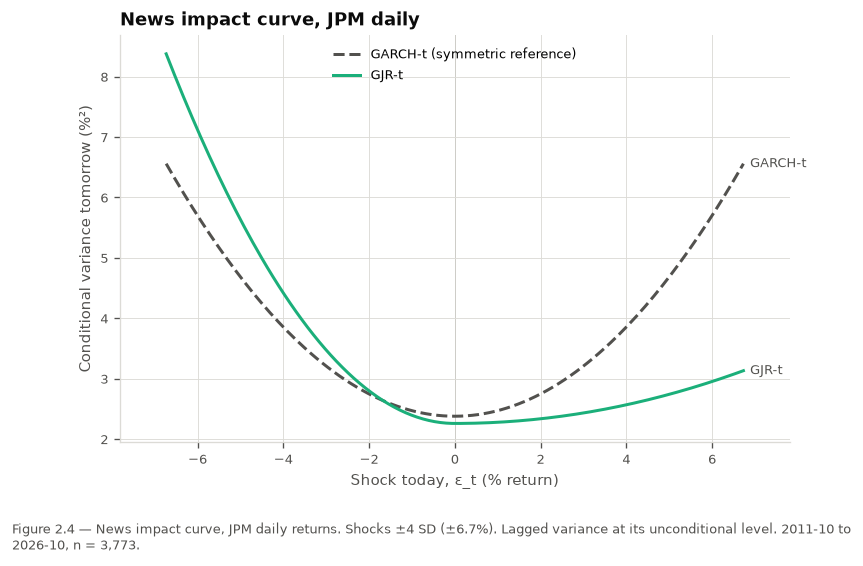

GJR-t    : next-day variance after a -4 SD shock 8.38, after +4 SD 3.13 (ratio 2.68).
EGARCH-t : next-day variance after a -4 SD shock 6.20, after +4 SD 2.88 (ratio 2.15).


In [19]:
daily_sd = r["daily"].std()
shocks = np.linspace(-4 * daily_sd, 4 * daily_sd, 201)
curves = {name: sf.news_impact(fits["daily"][name], shocks) for name in ("GARCH-t", "GJR-t", "EGARCH-t")}

fig, ax = plt.subplots(figsize=(7.2, 4.4))
# EGARCH's curve sits on a different level (log-variance), so it is quoted below, not drawn.
viz.news_impact_plot({k: curves[k] for k in ("GARCH-t", "GJR-t")}, TICKER, reference="GARCH-t", ax=ax)
ax.set_title(f"News impact curve, {TICKER} daily")
viz.caption(
    ax,
    f"Figure 2.4 — News impact curve, {TICKER} daily returns. Shocks ±4 SD (±{4 * daily_sd:.1f}%). "
    f"Lagged variance at its unconditional level. {period('daily')}, n = {len(r['daily']):,}.",
)
plt.show()

for name in ("GJR-t", "EGARCH-t"):
    left, right = curves[name].iloc[0], curves[name].iloc[-1]
    print(f"{name:<9}: next-day variance after a -4 SD shock {left:.2f}, after +4 SD {right:.2f} "
          f"(ratio {left / right:.2f}).")

The asymmetry is unmistakable. The GJR curve is steep on the left and nearly flat on the right: a
−4 SD day raises next-day variance about **2.7 times** as much as a +4 SD day; EGARCH gives about
2.2 times. This is the picture of Table 2.4's significant γ.

---

## B12 — Figure 2.5, standardised residuals

If GARCH captured *all* the non-normality, the standardised residuals z_t = ε_t / σ_t would be normal:
the fat tails would be nothing but a mixture of normals with changing variance. Fact 6 says they are
not. We test it on the residuals of the **GJR-t** model, the richest specification, against both the
normal and the Student-t the model itself estimated.

In [20]:
residuals = {frequency: fits[frequency][sf.PREFERRED_MODEL].std_resid for frequency in cfg.FREQUENCY_ORDER}
residual_stats = sf.descriptive_table(residuals)

table_2_1 = pd.concat([descriptive, residual_stats.rename(index=lambda f: f"{f}, std. residuals")])
print(f"Table 2.1 - Descriptive statistics, {TICKER} log returns and {sf.PREFERRED_MODEL} standardised "
      f"residuals. {period('daily')}. Residual rows are unit-variance by construction; "
      "their mean and SD are not in %.")
display(fmt.style(table_2_1, TABLE_2_1_RULES))

Table 2.1 - Descriptive statistics, JPM log returns and GJR-t standardised residuals. 2011-10 to 2026-10. Residual rows are unit-variance by construction; their mean and SD are not in %.


,n,Mean %,SD %,Min %,Max %,Skew,Skew p,Q-skew,Q-skew p,Excess kurtosis,Kurtosis p,JB stat,JB p,SW stat,SW p,AD stat,AD p
Series,,,,,,,,,,,,,,,,,
daily,"3,773",0.08,1.68,-16.21,16.56,-0.08,0.779,-0.05,0.035,11.08,<0.001,19291.68,<0.001,0.907,<0.001,55.80,<0.001
weekly,782,0.36,3.59,-21.87,20.10,-0.34,0.204,-0.13,0.004,4.06,<0.001,552.02,<0.001,0.959,<0.001,4.97,<0.001
monthly,179,1.48,6.98,-25.97,19.50,-0.66,0.029,-0.13,0.111,1.73,0.002,35.53,<0.001,0.970,<0.001,0.93,0.018
"daily, std. residuals","3,773",-0.01,1.00,-6.21,8.51,-0.09,0.664,-0.03,0.137,4.17,<0.001,2742.28,<0.001,0.966,<0.001,17.28,<0.001
"weekly, std. residuals",782,-0.03,1.01,-5.79,4.46,-0.49,0.032,-0.12,0.003,2.06,<0.001,169.21,<0.001,0.979,<0.001,2.45,<0.001
"monthly, std. residuals",179,-0.02,1.00,-3.59,2.68,-0.41,0.040,-0.17,0.043,0.65,0.087,8.08,0.018,0.987,0.084,0.77,0.044


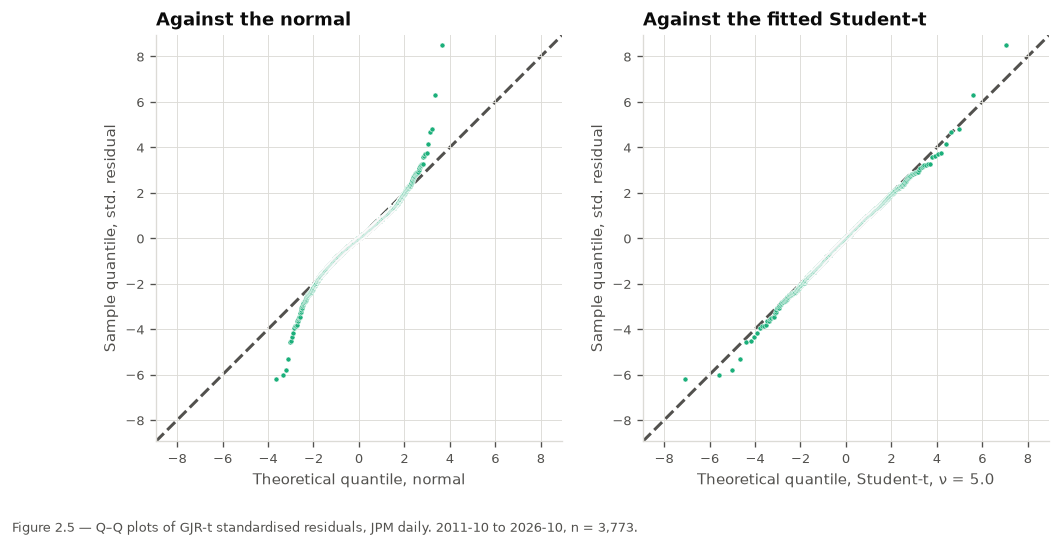

In [21]:
def residual_qq(frequency, number, appendix=False):
    z = residuals[frequency]
    nu = fits[frequency][sf.PREFERRED_MODEL].params["nu"]
    unit_t = stats.t(df=nu, scale=np.sqrt((nu - 2) / nu))  # unit-variance Student-t
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.4))
    viz.qq_plot(z, axes[0], TICKER, label="Std. residual")
    viz.qq_plot(z, axes[1], TICKER, label="Std. residual", dist=unit_t, dist_label=f"Student-t, ν = {nu:.1f}")
    axes[0].set_title("Against the normal")
    axes[1].set_title("Against the fitted Student-t")
    viz.caption(
        axes[0],
        f"Figure {number} — Q–Q plots of {sf.PREFERRED_MODEL} standardised residuals, {TICKER} {frequency}"
        f"{' (appendix)' if appendix else ''}. {period(frequency)}, n = {len(z):,}.",
    )
    plt.show()

residual_qq("daily", "2.5")

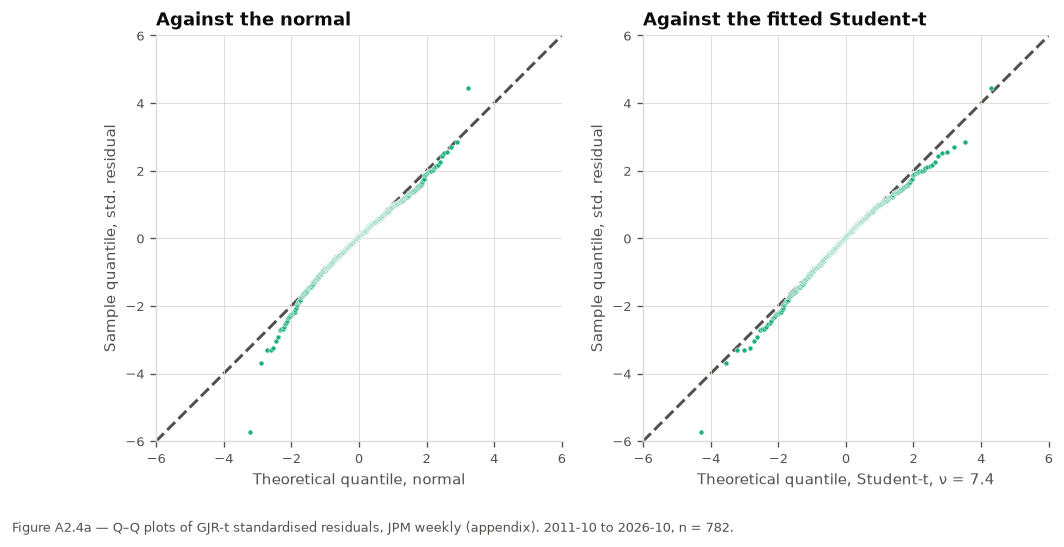

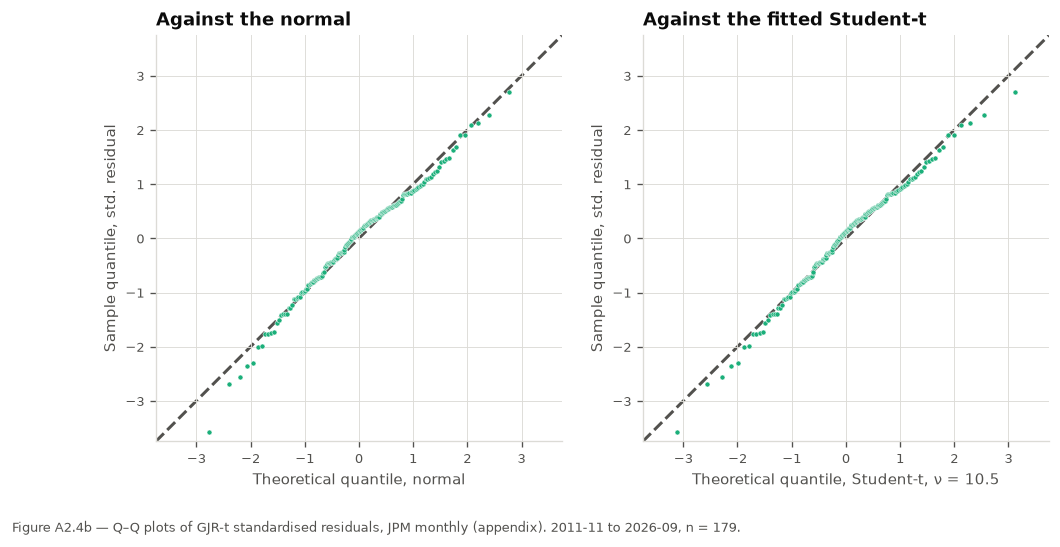

In [22]:
residual_qq("weekly", "A2.4a", appendix=True)
residual_qq("monthly", "A2.4b", appendix=True)

In [23]:
# Has the model absorbed the clustering? Ljung-Box on squared standardised residuals should not reject.
from statsmodels.stats.diagnostic import acorr_ljungbox

adequacy = pd.DataFrame(
    {frequency: acorr_ljungbox(z**2, lags=list(sf.LB_LAGS))["lb_pvalue"] for frequency, z in residuals.items()}
).T
adequacy.columns = [f"p({k})" for k in sf.LB_LAGS]
print(f"Model adequacy - Ljung-Box p-values on squared {sf.PREFERRED_MODEL} standardised residuals.")
display(fmt.style(adequacy, {c: fmt.pvalue for c in adequacy.columns}))

Model adequacy - Ljung-Box p-values on squared GJR-t standardised residuals.


,p(5),p(10),p(20)
daily,0.700,0.734,0.874
weekly,0.738,0.881,0.983
monthly,0.780,0.966,0.996


The adequacy check is read at daily and weekly frequency, where the model identifies clustering: once
each period is scaled by its conditional volatility, little clustering should be left in the squares.
The residuals are **still** fat-tailed there — daily excess kurtosis falls from about 11 to about 4,
weekly from about 4 to about 2, and Jarque–Bera rejects decisively. Against the normal the daily Q–Q
plot bends away in both tails; against the fitted t (ν ≈ 5) it sits close to the line. **Volatility
clustering explains part of the unconditional fat tails, not all of them** — the conditional
distribution is itself non-normal, which is exactly fact 6, and is why the Student-t error assumption
beats the normal so clearly in Table 2.4.

At monthly frequency the residuals still reject JB narrowly, but the monthly model identifies no
clustering, so these "residuals" are close to the standardised raw returns. Table 2.5 records
*Partial*: the evidence there is about the unconditional distribution, not the conditional one.

---

## B13 — Table 2.5, stylised facts summary

The verdict rules are fixed in `src/stylised.py` and printed below, so each cell is the mechanical
outcome of a stated rule rather than a judgment made after looking. All tests at the 5% level.

In [24]:
for fact, rule in sf.RULES.items():
    print(f"{fact}\n    {rule}\n")

1. Little or no serial correlation in raw returns
    Supported if the robust portmanteau does not reject at any of lags (5, 10, 20). Partial if it rejects but every |ρ_k|, k ≤ 20, is below 0.10 (detectable, economically negligible). Not supported otherwise.

2. Non-normal distribution, fat tails
    Supported if Jarque–Bera rejects and excess kurtosis is positive and significant (D'Agostino kurtosis test). Partial if only one of JB, Shapiro–Wilk, Anderson–Darling rejects, or kurtosis is not significant. Not supported if none rejects.

3. Asymmetry / negative skewness
    Two measures, each tested by moving-block bootstrap: moment skewness and quantile skewness (5%/95%). Supported if both are negative and significant. Partial if one is. Not supported if neither is (significant positive skew is reported in the evidence, but is not the negative kind the fact describes).

4. Volatility clustering
    Supported if Ljung–Box on |r| and r² and ARCH-LM all reject at every lag. Partial if some

In [25]:
verdicts = sf.verdicts(descriptive, dependence, acfs, fits, residual_stats)
print(f"Table 2.5 - Stylised facts summary, {TICKER}. {period('daily')}; "
      f"n = {len(r['daily']):,} / {len(r['weekly']):,} / {len(r['monthly']):,}. "
      "Rules as printed above; 5% significance.")
display(verdicts)

Table 2.5 - Stylised facts summary, JPM. 2011-10 to 2026-10; n = 3,773 / 782 / 179. Rules as printed above; 5% significance.


daily                                                     weekly                                                        monthly  \
                                                     Verdict                                        Evidence    Verdict                                        Evidence        Verdict   
Stylised fact                                                                                                                                                                            
1. Little or no serial correlation in raw returns    Partial           Q*(10) p=0.014; max |ρ| 0.08 at lag 1  Supported           Q*(10) p=0.750; max |ρ| 0.10 at lag 3      Supported   
2. Non-normal distribution, fat tails              Supported               Excess kurtosis 11.08; JB p<0.001  Supported                Excess kurtosis 4.06; JB p<0.001      Supported   
3. Asymmetry / negative skewness                     Partial      Skew -0.08, p=0.779; Q-skew -0.05, p=0.035    Partial      Skew -0.34, p=0.204; Q-skew -0.13, p=0.004        Partial   
4. Volatility clustering                           Supported            LB |r|(10) p<0.001; 9/9 tests reject  Supported            LB |r|(10) p<0.001; 9/9 tests reject  Not supported   
5. Leverage effect                                 Supported  GJR γ 0.116, p<0.001; EGARCH γ -0.093, p<0.001  Supported  GJR γ 0.195, p=0.003; EGARCH γ -0.181, p<0.001        Partial   
6. Conditional non-normality                       Supported     Resid. excess kurt. 4.17; JB p<0.001; ν 5.0  Supported     Resid. excess kurt. 2.06; JB p<0.001; ν 7.4        Partial   

                                                                                                                                   
                                                                                         Evidence                     Evidence in  
Stylised fact                                                                                                                      
1. Little or no serial correlation in raw returns           Q*(10) p=0.315; max |ρ| 0.19 at lag 4          Table 2.3, Figure 2.3a  
2. Non-normal distribution, fat tails                            Excess kurtosis 1.73; JB p<0.001      Tables 2.1–2.2, Figure 2.2  
3. Asymmetry / negative skewness                       Skew -0.66, p=0.029; Q-skew -0.13, p=0.111           Table 2.1, Figure 2.2  
4. Volatility clustering                                     LB |r|(10) p=0.730; 0/9 tests reject  Table 2.3, Figures 2.1, 2.3b–c  
5. Leverage effect                                 GJR γ 0.296, p=0.305; EGARCH γ -0.135, p=0.020           Table 2.4, Figure 2.4  
6. Conditional non-normality                         Resid. excess kurt. 0.65; JB p=0.018; ν 10.5           Table 2.1, Figure 2.5

In [26]:
# Compact view: verdicts only, the grid the report opens with.
grid = verdicts.xs("Verdict", axis=1, level=1)
display(grid)
print(grid.stack().value_counts().to_string())

,daily,weekly,monthly
Stylised fact,,,
1. Little or no serial correlation in raw returns,Partial,Supported,Supported
"2. Non-normal distribution, fat tails",Supported,Supported,Supported
3. Asymmetry / negative skewness,Partial,Partial,Partial
4. Volatility clustering,Supported,Supported,Not supported
5. Leverage effect,Supported,Supported,Partial
6. Conditional non-normality,Supported,Supported,Partial


Supported        11
Partial           6
Not supported     1


---

## Done-when checks

The plan's exit criteria for workstream B, asserted rather than eyeballed.

In [27]:
checks = []
grid = verdicts.xs("Verdict", axis=1, level=1)
allowed = {sf.SUPPORTED, sf.PARTIAL, sf.NOT_SUPPORTED}

# 1. A verdict in all 18 cells, from the allowed set.
checks.append(("Table 2.5 has a verdict in all 18 cells",
               grid.shape == (6, 3) and grid.isin(allowed).all().all()))

# 2. Every cell cites a statistic, and every row names a numbered table or figure.
evidence = verdicts.xs("Evidence", axis=1, level=1)
checks.append(("Every cell cites a statistic", evidence.notna().all().all() and (evidence != "").all().all()))
checks.append(("Every fact is backed by a numbered table or figure",
               verdicts[("", "Evidence in")].str.contains(r"(?:Table|Figure)s? 2\.\d").all()))

# 3. The analysis is not a rubber stamp: at least one honest 'Not supported'.
checks.append(("At least one cell says Not supported", (grid == sf.NOT_SUPPORTED).any().any()))

# 4. All three frequencies used complete periods only.
checks.append(("Weekly and monthly series are complete periods only",
               r["monthly"].index[-1] <= panel.calendar[-1] and r["weekly"].index[-1] <= panel.calendar[-1]))

# 5. Estimation problems are logged, not dropped: every model at every frequency has a result.
checks.append(("Every model fitted at every frequency, failures logged",
               all(len(f) == len(sf.MODELS) for f in fits.values())))

# 6. Skewness verdicts rest on tests valid under fat tails, not on the normal-theory test.
checks.append(("Skewness tested by bootstrap (moment and quantile)",
               {"Skew p", "Q-skew p"} <= set(descriptive.columns)))

# 7. The robustness checks ran on every variant.
checks.append(("Robustness tables complete, every variant converged",
               all(t["Converged"].all() for t in asymmetry.values())
               and len(sensitivity) == 2 * len(cfg.FREQUENCY_ORDER)))

for label, passed in checks:
    print(f"[{'PASS' if passed else 'FAIL'}] {label}")
assert all(passed for _, passed in checks), "Workstream B exit criteria not met"
print("\nWorkstream B complete.")

[PASS] Table 2.5 has a verdict in all 18 cells
[PASS] Every cell cites a statistic
[PASS] Every fact is backed by a numbered table or figure
[PASS] At least one cell says Not supported
[PASS] Weekly and monthly series are complete periods only
[PASS] Every model fitted at every frequency, failures logged
[PASS] Skewness tested by bootstrap (moment and quantile)
[PASS] Robustness tables complete, every variant converged

Workstream B complete.


---

## Handoff

Report section 3 consumes Tables 2.1–2.5 and Figures 2.1–2.5; the appendix takes Tables A2.1–A2.4 and
Figures A2.1–A2.4. Nothing here feeds the backtest — the portfolio strategies use simple returns from
`data.build_returns` directly.

Findings the later sections should carry forward:

| Finding | Where it matters |
| --- | --- |
| Daily volatility clustering with a half-life of about one month; regimes change within a quarter | Section 4: a trailing one-year covariance averages over several regimes, so risk-based weights react slowly to a volatility shock |
| Strong, robust leverage effect: falls raise volatility about 2.7× as much as rises | Section 5–6: drawdowns and volatility arrive together, so strategies that size by trailing volatility de-risk only after the fall |
| Conditional fat tails (t, ν ≈ 5) | Section 6: volatility and Sharpe-based comparisons understate tail risk; drawdown metrics are the necessary complement |
| Daily excess kurtosis halves without March 2020 | Section 6: any evaluation year that contains the crash will dominate its strategy's statistics |